# Exploratory Data Analysis
## Labor Force Participation Rate (World Bank, SL.TLF.CACT.ZS)

This notebook explores the cleaned dataset before any machine learning is done, as required by Section 4.2 of the assignment.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sqlalchemy import create_engine
import sys
sys.path.append('..')
from src.config import DATABASE_URL, BASE_DIR

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

DOCS_DIR = os.path.join(BASE_DIR, 'docs')
os.makedirs(DOCS_DIR, exist_ok=True)

engine = create_engine(DATABASE_URL)
df = pd.read_sql('SELECT * FROM clean_labor_force', engine)
df.head()

,id,country_name,country_iso3,year,labor_force_participation_rate,loaded_at
0,6718,Zimbabwe,ZWE,1990,66.989,2026-08-08 02:11:14.525335
1,9,Afghanistan,AFG,2025,37.457,2026-08-08 02:11:14.525335
2,10,Afghanistan,AFG,2024,37.547,2026-08-08 02:11:14.525335
3,11,Afghanistan,AFG,2023,37.588,2026-08-08 02:11:14.525335
4,12,Afghanistan,AFG,2022,37.640,2026-08-08 02:11:14.525335


## 1. Full Dataset Overview

In [5]:
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("Column types:")
print(df.dtypes)
print(f"\nMissing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"\nNumber of unique countries: {df['country_iso3'].nunique()}")
print(f"Year range: {df['year'].min()} - {df['year'].max()}")

Shape: 6718 rows, 6 columns

Column types:
id                                         int64
country_name                              object
country_iso3                              object
year                                       int64
labor_force_participation_rate           float64
loaded_at                         datetime64[ns]
dtype: object

Missing values per column:
id                                0
country_name                      0
country_iso3                      0
year                              0
labor_force_participation_rate    0
loaded_at                         0
dtype: int64

Duplicate rows: 0

Number of unique countries: 187
Year range: 1990 - 2025


## 2. Univariate Analysis

count    6718.000000
mean       61.089027
std        11.041316
min        23.123000
25%        54.797000
50%        61.157000
75%        67.209500
max        90.094000
Name: labor_force_participation_rate, dtype: float64


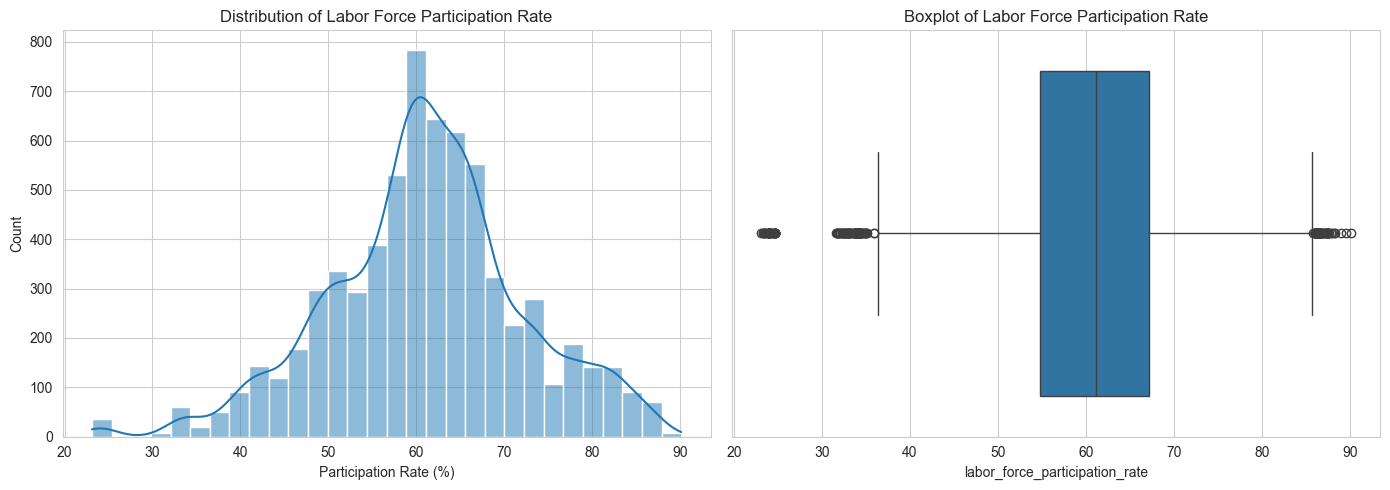

In [6]:
# Numeric column: labor_force_participation_rate
print(df['labor_force_participation_rate'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['labor_force_participation_rate'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Labor Force Participation Rate')
axes[0].set_xlabel('Participation Rate (%)')

sns.boxplot(x=df['labor_force_participation_rate'], ax=axes[1])
axes[1].set_title('Boxplot of Labor Force Participation Rate')
plt.tight_layout()
plt.savefig(os.path.join(DOCS_DIR, 'eda_univariate_numeric.png'), dpi=150)
plt.show()

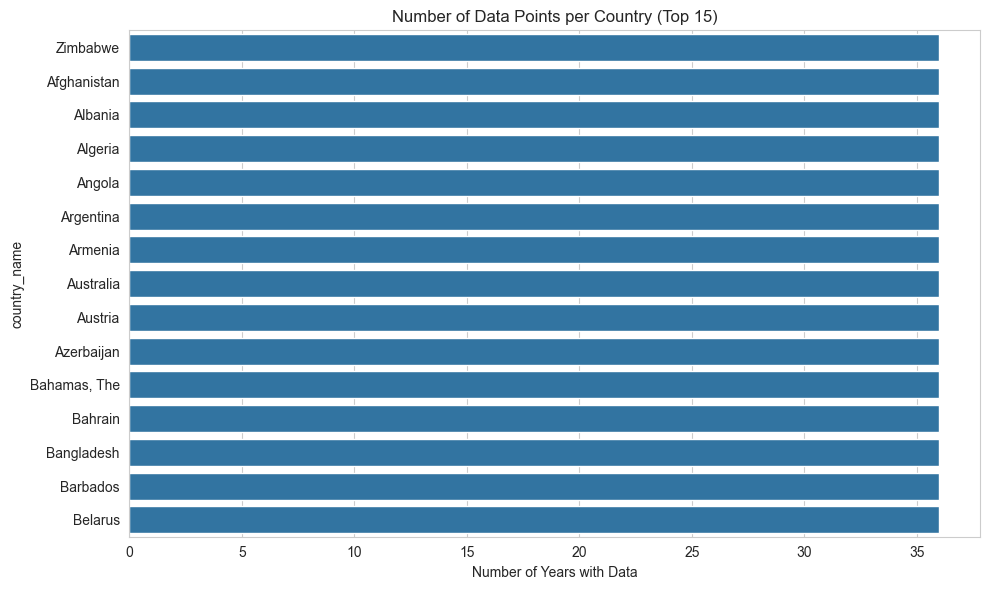

In [7]:
# Categorical column: country (top 15 by row count, since it's the main category)
top_countries = df['country_name'].value_counts().head(15)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title('Number of Data Points per Country (Top 15)')
plt.xlabel('Number of Years with Data')
plt.tight_layout()
plt.savefig(os.path.join(DOCS_DIR, 'eda_univariate_categorical.png'), dpi=150)
plt.show()

## 3. Bivariate Analysis: Rate vs. Year

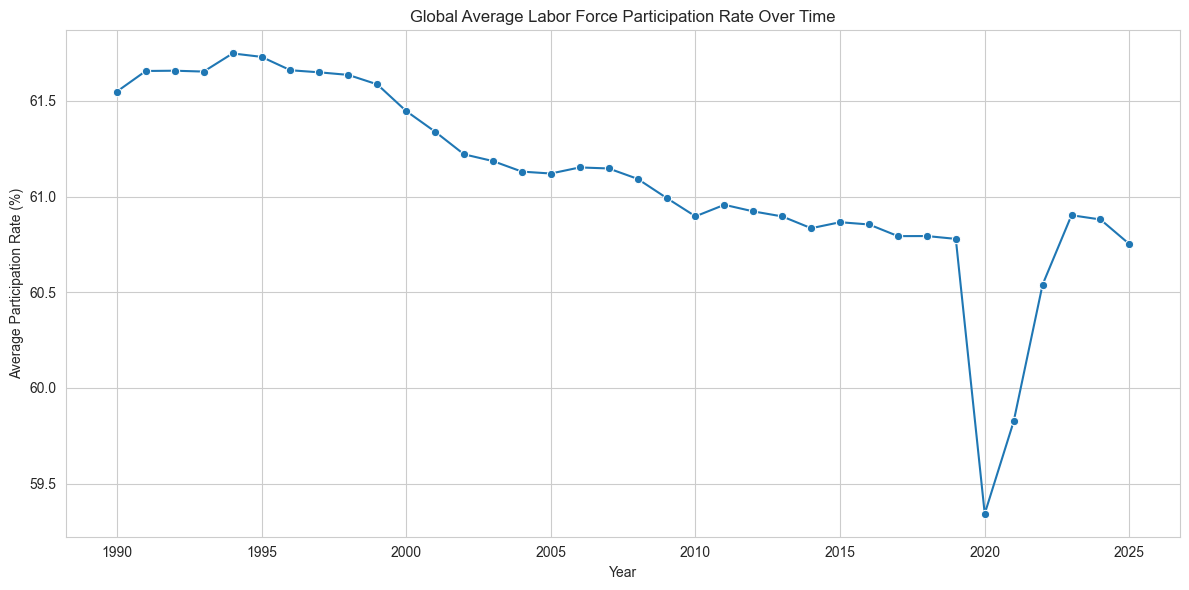

In [8]:
# Does the global average participation rate change over time?
yearly_avg = df.groupby('year')['labor_force_participation_rate'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_avg, x='year', y='labor_force_participation_rate', marker='o')
plt.title('Global Average Labor Force Participation Rate Over Time')
plt.xlabel('Year')
plt.ylabel('Average Participation Rate (%)')
plt.tight_layout()
plt.savefig(os.path.join(DOCS_DIR, 'eda_bivariate_trend.png'), dpi=150)
plt.show()

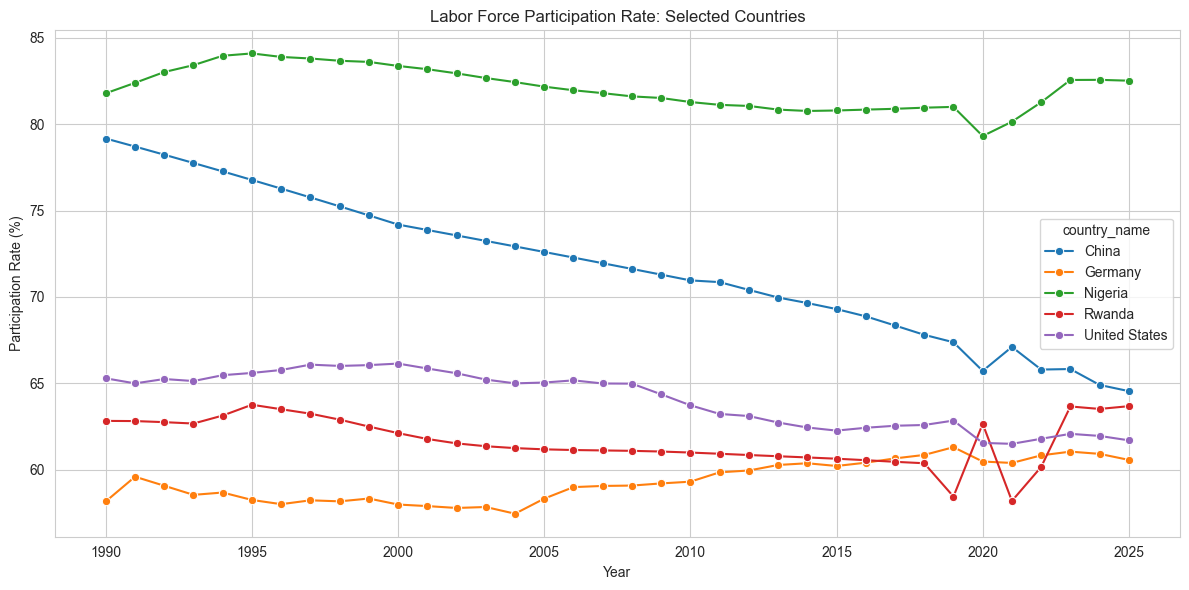

In [9]:
# Compare a handful of specific countries over time
sample_countries = ['RWA', 'USA', 'CHN', 'NGA', 'DEU']
subset = df[df['country_iso3'].isin(sample_countries)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=subset, x='year', y='labor_force_participation_rate', hue='country_name', marker='o')
plt.title('Labor Force Participation Rate: Selected Countries')
plt.xlabel('Year')
plt.ylabel('Participation Rate (%)')
plt.tight_layout()
plt.savefig(os.path.join(DOCS_DIR, 'eda_bivariate_countries.png'), dpi=150)
plt.show()

## 4. Written Summary

The cleaned dataset contains 6,718 observations across 187 countries from 1990–2025, with no missing values or duplicates after cleaning. Labor force participation rates average 61.1% globally, ranging from 23.1% to 90.1%, with a fairly symmetric distribution. The global average shows a slow decline over three decades, interrupted by a sharp drop around 2020 tied to the COVID-19 pandemic, then a partial recovery. Individual countries diverge sharply from this average: Rwanda maintains one of the highest and most stable participation rates in the sample (~80–84%), while China has seen a steady long-term decline (~79% to ~65%), reflecting major shifts in its economy and demographics. This variation across countries, more than the mild global trend, suggests country-level and regional factors will likely be stronger predictors than year alone, which matters for the machine learning stage.